# 09 — 接触力と摩擦円錐制約

MPCが数学的に選べる床反力の範囲を理解します。

**前提**: `08_srbd_dynamics.ipynb`

> 読み方: 「直感 → 数式 → 上流コード → 小実験 → 解釈」の順です。
> `実装事実` と書いた箇所は現行 `external/Quadruped-PyMPC` のコード、
> `学習用モデル` は理解のために単純化した再実装です。

In [1]:
from pathlib import Path
import os, sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook_pympc":
    ROOT = ROOT.parent
PYMPC_ROOT = ROOT / "external" / "Quadruped-PyMPC"
assert PYMPC_ROOT.exists(), f"Quadruped-PyMPC が見つかりません: {PYMPC_ROOT}"
if str(PYMPC_ROOT) not in sys.path:
    sys.path.insert(0, str(PYMPC_ROOT))

os.environ.setdefault("ACADOS_SOURCE_DIR", str(PYMPC_ROOT / "quadruped_pympc" / "acados"))
os.environ.setdefault("MUJOCO_GL", "egl")
print("workspace :", ROOT)
print("PyMPC root:", PYMPC_ROOT)

workspace : /home/takuya/work/mpc_dog
PyMPC root: /home/takuya/work/mpc_dog/external/Quadruped-PyMPC


## Coulomb摩擦

各脚について

\[
|F_x|\le\mu F_z,\quad |F_y|\le\mu F_z,\quad
F_z^{min}\le F_z\le F_z^{max}
\]

実装は円錐を4平面で近似します。摩擦係数 \(\mu\) を上げることは、
横力を無料で増やすことではなく、許容集合を広げることです。
Plantの地面摩擦とMPCの \(\mu\) が不一致なら、予測上可能でも実際には滑ります。

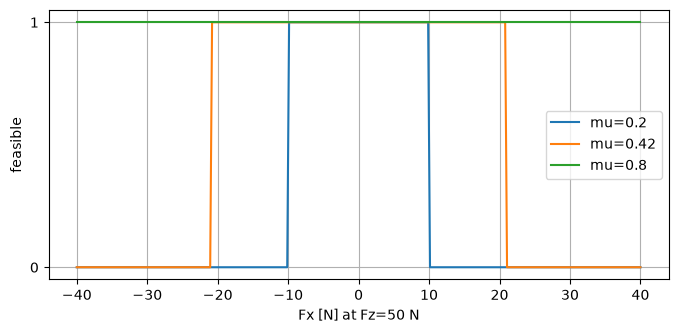

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fz = 50.0
fx = np.linspace(-40, 40, 301)
plt.figure(figsize=(8, 3.5))
for mu in [0.2, 0.42, 0.8]:
    feasible = np.abs(fx) <= mu * fz
    plt.plot(fx, feasible.astype(int), label=f"mu={mu}")
plt.xlabel("Fx [N] at Fz=50 N"); plt.ylabel("feasible")
plt.yticks([0,1]); plt.legend(); plt.grid(); plt.show()

In [3]:
def friction_margin(force, mu):
    """centroidal_nmpc_nominal.pyの4面摩擦角錐をmarginで表す。"""
    fx, fy, fz = force  # [N], world座標の1脚GRF

    # 制約 |Fx|<=mu*Fz, |Fy|<=mu*Fz, Fz>=0 を
    # 右辺-左辺へ直す。最小margin<0なら少なくとも1面を違反。
    margins = [
        mu * fz - abs(fx),  # x方向Coulomb制約
        mu * fz - abs(fy),  # y方向Coulomb制約
        fz,                 # 地面は脚を引張れない
    ]
    return min(margins)

tests = [np.array([10,5,50]), np.array([25,0,50]), np.array([0,0,-1])]
for force in tests:
    margin = friction_margin(force, mu=0.42)
    print(force, "margin =", margin, "N", "feasible =", margin >= 0)

[10  5 50] margin = 11.0 N
[25  0 50] margin = -4.0 N
[ 0  0 -1] margin = -1 N


marginが0に近い脚が継続するなら、まず速度指令・姿勢誤差・足配置を確認します。
\(\mu\) を無根拠に上げると、sim内だけ成功する制御器になります。

## 章末チェック

出力を眺めるだけでなく、次を自分の言葉で答えてください。

1. この章の入力・出力の shape、単位、座標系は何か。
2. 変更可能な量と、他の章から渡される量は何か。
3. パラメータを2倍にしたとき、どのグラフがどちらへ変化するか。
4. 現行実装の事実と、学習用の近似を区別できるか。